In [18]:
library(tidyverse)
library(janitor)
library(tidymodels)

In [19]:
data <- read_csv("hells_kitchen_frame.csv")

Rows: 264 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): season_number, Contestant, Occupation, Hometown, contestant_urls, B...
dbl (5): Age, Challenges Won, Services Won, Times as BoW/Announcer, Times No...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Cleaning the data

In [20]:
data <- clean_names(data)

In [21]:
glimpse(data)

Rows: 264
Columns: 14
$ season_number                  <chr> "Season 1", "Season 1", "Season 1", "Se…
$ contestant                     <chr> "Andrew Bonito", "Jessica Cabo", "Jimmy…
$ age                            <dbl> 24, 26, 25, 27, 33, 28, 32, 35, 36, 40,…
$ occupation                     <chr> "Office Assistant", "Headhunter", "Purc…
$ hometown                       <chr> "Livingston, NJ", "Huntington, NY", "Wi…
$ contestant_urls                <chr> "https://hellskitchen.fandom.com/wiki/A…
$ blind_taste_test_score         <chr> "1 out of 4", "0 out of 4", "1 out of 4…
$ challenges_won                 <dbl> 1, 1, 5, 1, 1, 2, 0, 3, 2, 5, 0, 4, 0, …
$ services_won                   <dbl> 3, 3, 3, 2, 0, 0, 2, 2, 3, 3, 0, 5, 1, …
$ times_as_bo_w_announcer        <dbl> 0, 2, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, …
$ times_nominated                <dbl> 3, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 2, …
$ placement                      <chr> "6th", "3rd", "5th", "8th", "11th", "10…
$ episode_eliminat

In [22]:
new_data <- data |> mutate(
    placement = str_replace(placement, "Winner", "1"),
    placement = str_replace(placement, "Runner-up", "2"),
    placement = as.numeric(gsub("\\D+", "", placement)))
glimpse(data)

Rows: 264
Columns: 14
$ season_number                  <chr> "Season 1", "Season 1", "Season 1", "Se…
$ contestant                     <chr> "Andrew Bonito", "Jessica Cabo", "Jimmy…
$ age                            <dbl> 24, 26, 25, 27, 33, 28, 32, 35, 36, 40,…
$ occupation                     <chr> "Office Assistant", "Headhunter", "Purc…
$ hometown                       <chr> "Livingston, NJ", "Huntington, NY", "Wi…
$ contestant_urls                <chr> "https://hellskitchen.fandom.com/wiki/A…
$ blind_taste_test_score         <chr> "1 out of 4", "0 out of 4", "1 out of 4…
$ challenges_won                 <dbl> 1, 1, 5, 1, 1, 2, 0, 3, 2, 5, 0, 4, 0, …
$ services_won                   <dbl> 3, 3, 3, 2, 0, 0, 2, 2, 3, 3, 0, 5, 1, …
$ times_as_bo_w_announcer        <dbl> 0, 2, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, …
$ times_nominated                <dbl> 3, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 2, …
$ placement                      <chr> "6th", "3rd", "5th", "8th", "11th", "10…
$ episode_eliminat

In [23]:
new_data <- new_data |> mutate(blind_taste_test_score_numeric = parse_number(blind_taste_test_score) /
           parse_number(str_extract(blind_taste_test_score, "(?<=out of )\\d+")))

new_data <- new_data |> mutate(signature_dish_score_numeric = parse_number(signature_dish_challenge_score) /
           parse_number(str_extract(signature_dish_challenge_score, "(?<=out of )\\d+")))


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `blind_taste_test_score_numeric = `/`(...)`.
Caused by warning:
! 1 parsing failure.
row col expected actual
 36  -- a number    N/A”


In [24]:
View(new_data)

season_number,contestant,age,occupation,hometown,contestant_urls,blind_taste_test_score,challenges_won,services_won,times_as_bo_w_announcer,times_nominated,placement,episode_eliminated_withdrew,signature_dish_challenge_score,blind_taste_test_score_numeric,signature_dish_score_numeric
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
Season 1,Andrew Bonito,24,Office Assistant,"Livingston, NJ",https://hellskitchen.fandom.com/wiki/Andrew_Bonito,1 out of 4,1,3,0,3,6,Day 6,NA,0.2500000,NA
Season 1,Jessica Cabo,26,Headhunter,"Huntington, NY",https://hellskitchen.fandom.com/wiki/Jessica_Cabo,0 out of 4,1,3,2,2,3,Day 9,NA,0.0000000,NA
Season 1,Jimmy Casey,25,Purchasing Supervisor,"Williston Park, NY",https://hellskitchen.fandom.com/wiki/Jimmy_Casey,1 out of 4,5,3,0,1,5,Day 7,NA,0.2500000,NA
Season 1,Mary Ellen Daniels,27,Bartender,"Belmont, MA",https://hellskitchen.fandom.com/wiki/Mary_Ellen_Daniels,NA,1,2,0,1,8,Day 4,NA,NA,NA
Season 1,Jeffery Dewberry,33,Pastry Chef,"Stockbridge, GA",https://hellskitchen.fandom.com/wiki/Jeffery_Dewberry,NA,1,0,0,2,11,Day 2,NA,NA,NA
Season 1,Jeff LaPoff,28,Finance Manager,"Orange, NJ",https://hellskitchen.fandom.com/wiki/Jeff_LaPoff,NA,2,0,0,1,10,Day 3,NA,NA,NA
Season 1,Wendy Liu,32,Account Manager,"Millburn, NJ",https://hellskitchen.fandom.com/wiki/Wendy_Liu,NA,0,2,0,1,9,Day 3,NA,NA,NA
Season 1,Chris North,35,Executive Chef,"Yorktown Heights, NY",https://hellskitchen.fandom.com/wiki/Chris_North,NA,3,2,1,1,7,Day 5,NA,NA,NA
Season 1,Ralph Pagano,36,Professional Chef,"Livingston, NJ",https://hellskitchen.fandom.com/wiki/Ralph_Pagano,0 out of 2,2,3,2,1,2,NA,NA,0.0000000,NA


## Feature Engineering

In [25]:
selected <- new_data |> select(season_number,contestant, age,
                               challenges_won,services_won,times_as_bo_w_announcer,times_nominated, placement,
                               blind_taste_test_score_numeric,
                               signature_dish_score_numeric) 

In [26]:
selected <- selected |> mutate(top_3 = ifelse(placement <= 3,1,0),
                                winner = ifelse(placement == 1, 1, 0),
                              top_3 = as_factor(top_3),
                               winner = as_factor(winner))

selected

season_number,contestant,age,challenges_won,services_won,times_as_bo_w_announcer,times_nominated,placement,blind_taste_test_score_numeric,signature_dish_score_numeric,top_3,winner
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
Season 1,Andrew Bonito,24,1,3,0,3,6,0.2500000,NA,0,0
Season 1,Jessica Cabo,26,1,3,2,2,3,0.0000000,NA,1,0
Season 1,Jimmy Casey,25,5,3,0,1,5,0.2500000,NA,0,0
Season 1,Mary Ellen Daniels,27,1,2,0,1,8,NA,NA,0,0
Season 1,Jeffery Dewberry,33,1,0,0,2,11,NA,NA,0,0
Season 1,Jeff LaPoff,28,2,0,0,1,10,NA,NA,0,0
Season 1,Wendy Liu,32,0,2,0,1,9,NA,NA,0,0
Season 1,Chris North,35,3,2,1,1,7,NA,NA,0,0
Season 1,Ralph Pagano,36,2,3,2,1,2,0.0000000,NA,1,0


## Data Relationships

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


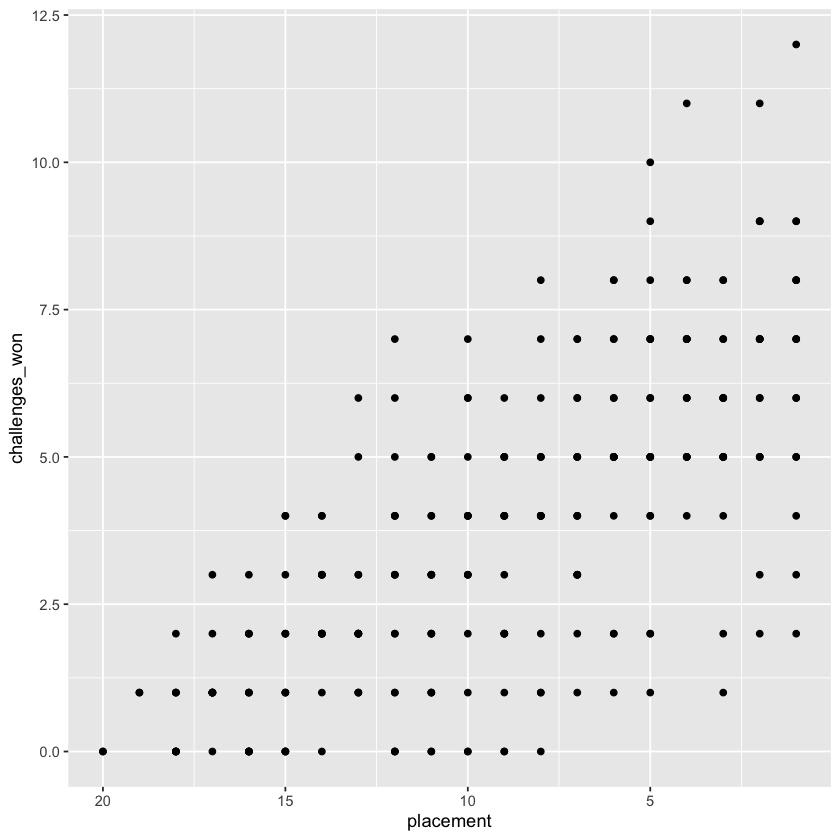

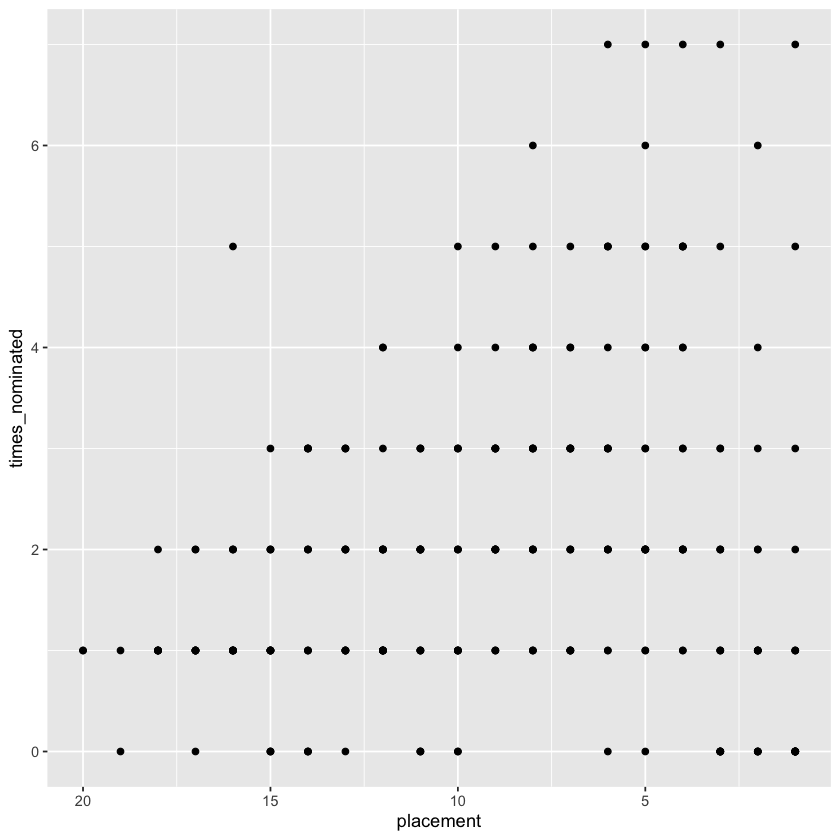

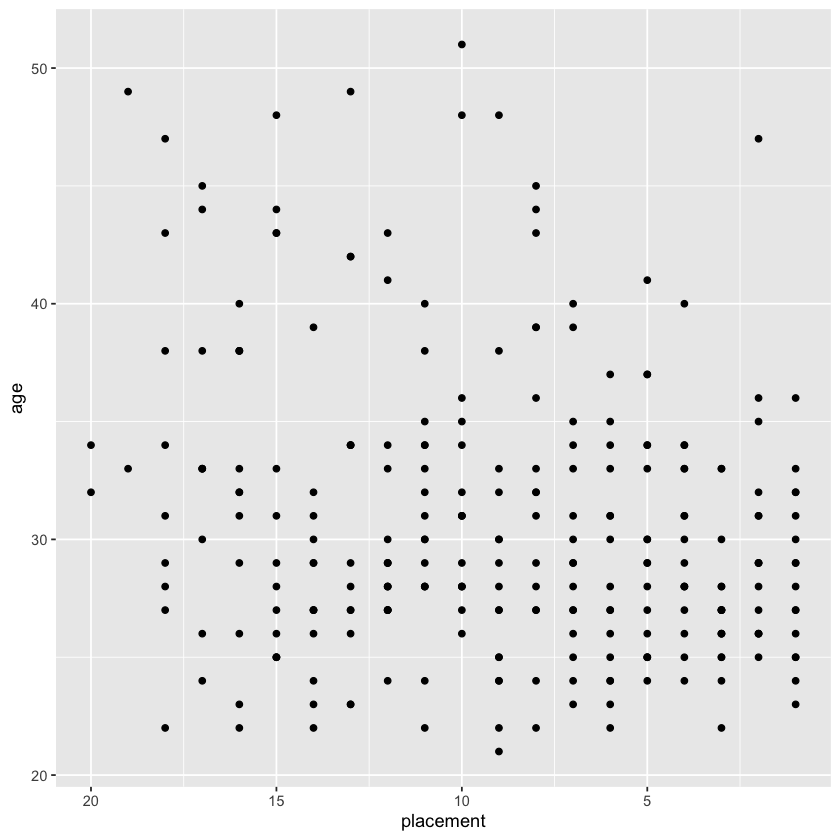

In [72]:
selected |> ggplot(aes(x = placement, y = challenges_won)) + geom_point() + scale_x_reverse()
selected |> ggplot(aes(x = placement, y = times_nominated)) + geom_point() + scale_x_reverse()
selected |> ggplot(aes(x = placement, y = age)) + geom_point() + scale_x_reverse()

## Model

In [164]:
set.seed(1)
contestant_data <- select(selected, -season_number, -contestant)

contestant_split <- initial_split(contestant_data, prop = 0.75, strata = top_3)
contestant_train <- training(contestant_split)
contestant_test <- testing(contestant_split)

In [165]:
glimpse(contestant_data)

Rows: 264
Columns: 10
$ age                            <dbl> 24, 26, 25, 27, 33, 28, 32, 35, 36, 40,…
$ challenges_won                 <dbl> 1, 1, 5, 1, 1, 2, 0, 3, 2, 5, 0, 4, 0, …
$ services_won                   <dbl> 3, 3, 3, 2, 0, 0, 2, 2, 3, 3, 0, 5, 1, …
$ times_as_bo_w_announcer        <dbl> 0, 2, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, …
$ times_nominated                <dbl> 3, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 2, …
$ placement                      <dbl> 6, 3, 5, 8, 11, 10, 9, 7, 2, 4, 12, 1, …
$ blind_taste_test_score_numeric <dbl> 0.2500000, 0.0000000, 0.2500000, NA, NA…
$ signature_dish_score_numeric   <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ top_3                          <fct> 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, …
$ winner                         <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, …


In [166]:
log_spec <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")

log_recipe <- recipe(top_3 ~ signature_dish_score_numeric + times_nominated + times_as_bo_w_announcer  , data = contestant_train)

In [167]:
log_fit <- workflow() |>
  add_recipe(log_recipe) |>
  add_model(log_spec) |>
  fit(data = contestant_train)
log_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: logistic_reg()

── Preprocessor ────────────────────────────────────────────────────────────────
0 Recipe Steps

── Model ───────────────────────────────────────────────────────────────────────

Call:  stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
                 (Intercept)  signature_dish_score_numeric  
                     -3.1231                        1.1979  
             times_nominated       times_as_bo_w_announcer  
                     -0.4885                        1.2778  

Degrees of Freedom: 136 Total (i.e. Null);  133 Residual
  (60 observations deleted due to missingness)
Null Deviance:	    120.7 
Residual Deviance: 82.43 	AIC: 90.43

In [168]:
prediction_results <- log_fit |>
  predict(contestant_test) |>
  bind_cols(contestant_test) 

log_test_results <- prediction_results |>
  metrics(truth = top_3, estimate = .pred_class)

In [169]:
log_test_results


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.9375000
kap,binary,0.7857143


In [170]:
prediction_results |> pull(top_3) |> levels()

[1] "0" "1"

In [171]:

 prediction_results |>
  precision(truth = top_3, estimate = .pred_class, event_level = "second")
  
  prediction_results |>
  recall(truth = top_3, estimate = .pred_class, event_level = "second")
  
  confusion <- prediction_results |>
             conf_mat(truth = top_3, estimate = .pred_class)
confusion |> View()

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.875


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.7777778


          Truth
Prediction  0  1
         0 38  2
         1  1  7